In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
import util
from jax import numpy as jnp
from importlib import reload
import re
import math

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [3]:
tab = Table.read("C:/Users/Ruben/Desktop/All_candidates_200pc_noparallaxovererror.vot")

### z dependence of stars with inaccurate parallaxe measurment

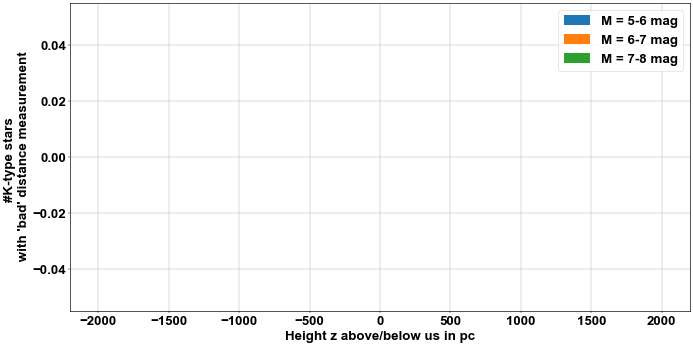

Requirement: parallax/standarterror(parallax) is larger than 0. This ensures useful parallax measurment. Removes an additional 0.00e+00 sources
We are left with 6.45e+05 sources
Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 2.50e+03 sources
We are left with 6.42e+05 sources


In [63]:
# Distance
deg2rad = np.pi/180.
dist_pc = 1000./tab["parallax"] # in pc
# Absolute magnitude
apparent_magnitude = np.array(tab["phot_g_mean_mag"]) # 3.15 - 19.00
absolute_magnitude = apparent_magnitude - 5.*np.log10(dist_pc) + 5

parallax_over_error = np.array(tab["parallax"]/tab["parallax_error"])
min = 0
mask0 = parallax_over_error > min
group1 = (absolute_magnitude[~mask0] >= 5) & (absolute_magnitude[~mask0] < 6)
group2 = (absolute_magnitude[~mask0] >= 6) & (absolute_magnitude[~mask0] < 7)
group3 = (absolute_magnitude[~mask0] >= 7) & (absolute_magnitude[~mask0] <= 8)
z_out = (dist_pc*np.sin(tab["b"]*deg2rad))[~mask0]
absolute_magnitude_out = absolute_magnitude[~mask0]

fig = plt.figure(figsize=(20,10))
plt.hist([z_out[group1], z_out[group2], z_out[group3]], bins=44, stacked=True, range=(-2000, 2000), label=["M = 5-6 mag", "M = 6-7 mag", "M = 7-8 mag"])
plt.xlabel("Height z above/below us in pc")
plt.ylabel("#K-type stars \n with 'bad' distance measurement")
plt.grid()
plt.legend()
fig.set_dpi(40)
plt.show()

print("Requirement: parallax/standarterror(parallax) is larger than {}. This ensures useful parallax measurment. Removes an additional {:.2e} sources".format(min, np.nansum(~mask0)))
print("We are left with {:.2e} sources".format(np.nansum(mask0)))

# # Cylinder with radius r_cyl #obsolete
# r_cyl = 200. # pc # parallax > cos(lat)*5
# mask = dist_pc * np.cos(tab["b"]*deg2rad) < r_cyl # 200 pc cylinder 
# print("Requirement: Inside the cylinder of {} pc radius. Removes {:.2e} of {:.2e} sources".format(r_cyl, np.nansum(~mask), mask.size))
# print("We are left with {:.2e} sources".format(np.nansum(mask)))

# Cylinder symmetrical around galactic plane
height = 1800. # pc
mask1 = (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)<height-14.5) & (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)>-height-14.5)
print("Requirement: Inside the cylinder of 2 * {} pc hight (centered at galactic plane!). Removes an additional {:.2e} sources".format(height, np.nansum(~mask1)))
print("We are left with {:.2e} sources".format(np.nansum(mask1)))

#### Selecting a subsample

In [65]:
def filtration(am_min = 5.0, am_max = 8.0):
# make this smaller for better volume completeness (default 8.0)

    # Absolute magnitude limits
    mask2 = (absolute_magnitude[mask0&mask1]>=am_min) & (absolute_magnitude[mask0&mask1]<=am_max)
    print("Requirement: Absolute magnitude between {} and {}. Removes an additional {:.2e} sources".format(am_min, am_max, np.nansum(~mask2)))
    print("We are left with {:.2e} sources".format(np.nansum(mask2)))
    tab_filtered = tab[mask0][mask1][mask2]

    return tab_filtered

In [66]:
# Load into separate numpy arrays
def arrays(tab_filtered):
    np_arr = np.array(tab_filtered)

    l_np = np_arr["l"]
    b_np = np_arr["b"]
    ra_np = np_arr["ra"]
    ra_error_np = np_arr["ra_error"]
    dec_np = np_arr["dec"]
    dec_error_np = np_arr["dec_error"]
    parallax_np = np_arr["parallax"]
    parallax_error_np = np_arr["parallax_error"]
    pmra_np = np_arr["pmra"]
    pmra_error_np = np_arr["pmra_error"]
    pmdec_np = np_arr["pmdec"]
    pmdec_error_np = np_arr["pmdec_error"]
    phot_g_mean_mag_np = np_arr["phot_g_mean_mag"]
    teff_gspphot_np = np_arr["teff_gspphot"]
    bp_rp_np = np_arr["bp_rp"]
    radial_velocity_np = np_arr["radial_velocity"]
    radial_velocity_error_np = np_arr["radial_velocity_error"]

    del np_arr

    return l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np

In [67]:
###  Functions for computing the vertical velocity
def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def pm_eq_to_pm_gal(mu_alpha_cos_delta, mu_delta, alpha, delta):
    ''' In- and Output in degrees per arbitrary unit of time'''
    # from https://arxiv.org/pdf/1306.2945
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    _delta = delta * deg2rad
    _alpha = alpha * deg2rad
    C1 = np.sin(deltaG)*np.cos(_delta) - np.cos(deltaG)*np.sin(_delta)*np.cos(_alpha-alphaG)
    C2 = np.cos(deltaG)*np.sin(_alpha-alphaG)
    cos_b = np.sqrt(C1**2 + C2**2)
    mu_l_cos_b = (C1*mu_alpha_cos_delta + C2*mu_delta)/cos_b
    mu_b = (-C2*mu_alpha_cos_delta + C1*mu_delta)/cos_b
    return mu_l_cos_b, mu_b

def ra_dec_to_l_b(ra, dec):
    '''From ra and dec in degrees to l and b in degrees'''
    # See http://www.iausofa.org/2023_1011_C/sofa/icrs2g.c
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    l_ANGE = 32.93192 * deg2rad
    _ra = ra * deg2rad
    _dec = dec * deg2rad
    
    b = np.arcsin(np.cos(_dec)*np.cos(deltaG)*np.cos(_ra-alphaG)+np.sin(_dec)*np.sin(deltaG))
    x = np.sin(_ra-alphaG)*np.cos(_dec)
    y = np.sin(_dec)*np.cos(deltaG)-np.cos(_dec)*np.sin(deltaG)*np.cos(_ra-alphaG)
    
    l = np.arctan2(y, x) + l_ANGE
    l = np.mod(l, 2.*np.pi)
    
    return l/deg2rad, b/deg2rad

def compute_vz(plx, ra, dec, vlos, pm_ra, pm_dec,):
    """From 
    parallax in mas,
    ra and dec in degrees,
    vlos in km/s,
    pm_ra and pm_dec in mas/yr,
    to vz in km/s"""
    deg2rad = np.pi / 180.
    yr_to_sec = 3.154e7
    pc_to_km = 3.086e13
    mas_to_deg = 1./60./60./1000.
    _pm_ra = pm_ra * mas_to_deg # deg/yr
    _pm_dec = pm_dec * mas_to_deg # deg/yr
    
    pm_l, pm_b = pm_eq_to_pm_gal(_pm_ra, _pm_dec, ra, dec)  # deg/yr
    pm_l *=  deg2rad / yr_to_sec # rad/s
    pm_b *= deg2rad / yr_to_sec # rad/s

    l, b = ra_dec_to_l_b(ra, dec) # deg
    l *= deg2rad # rad
    b *= deg2rad # rad

    r = r_from_plx(plx) * pc_to_km  # km
    v_z = vlos * np.sin(b) + r * np.cos(b) * pm_b  # km/s
    
    return v_z

# Vertical Distribution

In [68]:
def Verarbeitung(am_min, am_max, n_bin, range, Plot, half = False):
    # Histogram in z
    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) + 14.5 #correction for height of the sun above the galactic plane
    
    plt.figure(figsize=(20,10))
    n, bins, _ = plt.hist(z_np, bins=n_bin, range=(-range, range))
    plt.yscale("log")
    plt.xlabel("Height z above/below us in pc")
    plt.ylabel("#K-type stars")
    plt.grid()

    if Plot:
        plt.show()

    else:
        plt.close()

    # Create a text file
    if half:
        np.savetxt(f'real data/n_{am_min*10:.0f}{am_max*10:.0f}_o.txt', n, fmt='%i')
        np.savetxt(f'real data/bins_{am_min*10:.0f}{am_max*10:.0f}_o.txt', bins, fmt='%f')
    else:
        np.savetxt(f'real data/n_{am_min:.0f}{am_max:.0f}_o.txt', n, fmt='%i')
        np.savetxt(f'real data/bins_{am_min:.0f}{am_max:.0f}_o.txt', bins, fmt='%f')

Verarbeitung(5.0, 6.0, 40, 1800, False)
Verarbeitung(5.0, 5.5, 40, 1800, False, True)
Verarbeitung(5.5, 6.0, 40, 1800, False, True)
Verarbeitung(5.0, 6.5, 120, 1800, False, True)
Verarbeitung(5.5, 6.5, 120, 1800, False, True)
Verarbeitung(5.0, 7.0, 120, 1800, False)
Verarbeitung(6.0, 7.0, 120, 1800, False)
Verarbeitung(7.0, 8.0, 120, 1800, False)
Verarbeitung(7.0, 7.5, 40, 1800, False, True)
Verarbeitung(7.5, 8.0, 40, 1800, False, True)
Verarbeitung(5.0, 8.0, 200, 1800, False)

Requirement: Absolute magnitude between 5.0 and 6.0. Removes an additional 5.97e+05 sources
We are left with 4.53e+04 sources
Requirement: Absolute magnitude between 5.0 and 5.5. Removes an additional 6.36e+05 sources
We are left with 6.42e+03 sources
Requirement: Absolute magnitude between 5.5 and 6.0. Removes an additional 6.03e+05 sources
We are left with 3.89e+04 sources
Requirement: Absolute magnitude between 5.0 and 6.5. Removes an additional 4.76e+05 sources
We are left with 1.66e+05 sources
Requirement: Absolute magnitude between 5.5 and 6.5. Removes an additional 4.83e+05 sources
We are left with 1.60e+05 sources
Requirement: Absolute magnitude between 5.0 and 7.0. Removes an additional 3.44e+05 sources
We are left with 2.99e+05 sources
Requirement: Absolute magnitude between 6.0 and 7.0. Removes an additional 3.89e+05 sources
We are left with 2.53e+05 sources
Requirement: Absolute magnitude between 7.0 and 8.0. Removes an additional 3.97e+05 sources
We are left with 2.45e+05 

Requirement: Absolute magnitude between 5.0 and 6.075. Removes an additional 5.82e+05 sources
We are left with 5.99e+04 sources
Requirement: Absolute magnitude between 6.075 and 6.324. Removes an additional 5.82e+05 sources
We are left with 6.01e+04 sources
Requirement: Absolute magnitude between 6.324 and 6.554. Removes an additional 5.82e+05 sources
We are left with 6.01e+04 sources
Requirement: Absolute magnitude between 6.554 and 6.78. Removes an additional 5.82e+05 sources
We are left with 5.99e+04 sources
Requirement: Absolute magnitude between 6.78 and 7.005. Removes an additional 5.82e+05 sources
We are left with 6.00e+04 sources
Requirement: Absolute magnitude between 7.005 and 7.23. Removes an additional 5.82e+05 sources
We are left with 6.00e+04 sources
Requirement: Absolute magnitude between 7.23 and 7.462. Removes an additional 5.82e+05 sources
We are left with 6.01e+04 sources
Requirement: Absolute magnitude between 7.462 and 7.714. Removes an additional 5.82e+05 sources


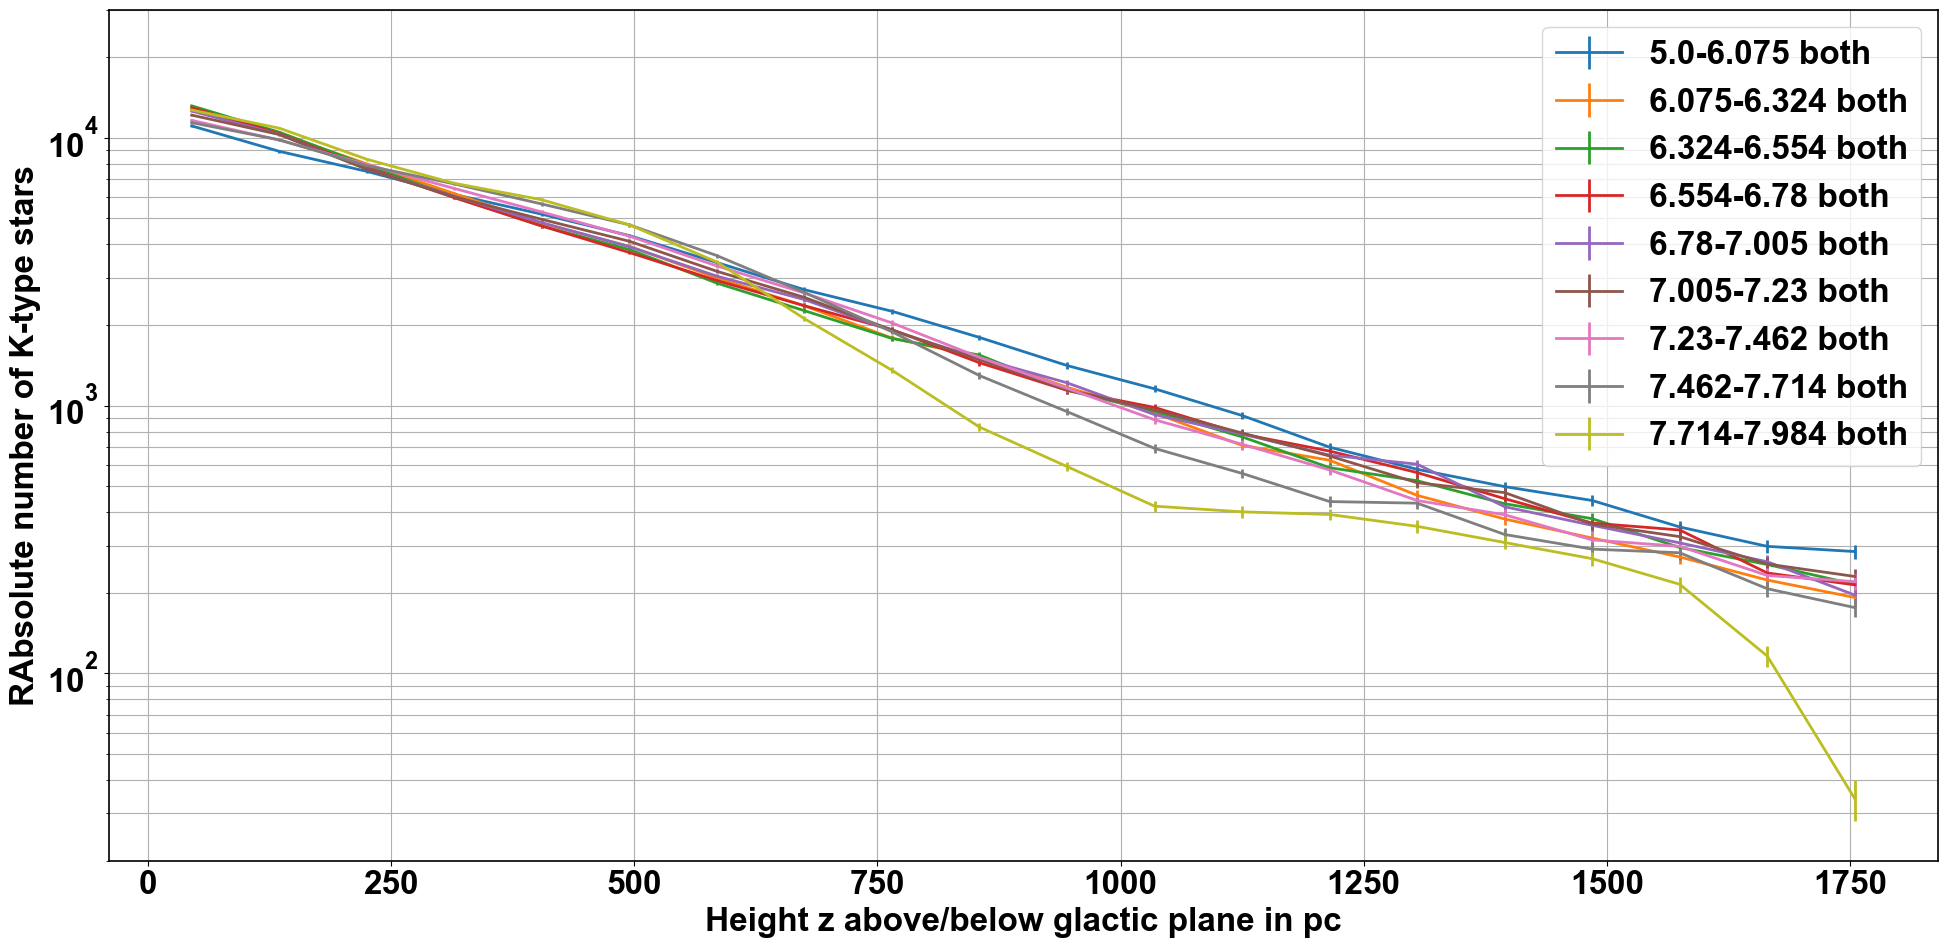

In [69]:
fig, ax = plt.subplots(1,1, figsize=(20,10), gridspec_kw={'height_ratios': [1]}, sharex=True)
ax.set_yscale("log")
ax.set_xlabel("Height z above/below glactic plane in pc")
ax.set_ylabel("RAbsolute number of K-type stars")
ax.set_ylim(20, 3e+4)

def slice(am_min, am_max, n_bin):
    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) + 14.5 #correction for height of the sun above the galactic plane
    
    n, bins = np.histogram(z_np, bins=n_bin, range=(-1800, 1800))
    zz = (bins[1:]+bins[:-1])/2
    pos = np.where(zz >= 0)
    neg = np.where(zz < 0)
    n_sum = (n[pos]+np.flip(n[neg]))
    # ax.errorbar(zz[pos], n[pos], yerr=np.sqrt(n[pos]), label=f"{am_min}-{am_max} pos")
    # ax.errorbar(abs(zz[neg]), n[neg], yerr=np.sqrt(n[neg]), label=f"{am_min}-{am_max} neg")
    ax.errorbar(zz[pos], n_sum, yerr=np.sqrt(n_sum), label=f"{am_min}-{am_max} both")

slice(5.0, 6.075, 40)
slice(6.075, 6.324, 40)
slice(6.324, 6.554, 40)
slice(6.554, 6.780, 40)
slice(6.780, 7.005, 40)
slice(7.005, 7.230, 40)
slice(7.230, 7.462, 40)
slice(7.462, 7.714, 40)
slice(7.714, 7.984, 40)

ax.grid(which='both')
ax.legend()
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
fig.set_dpi(100)
plt.show()


Requirement: Absolute magnitude between 5.0 and 6.181. Removes an additional 5.58e+05 sources
We are left with 8.40e+04 sources
Requirement: Absolute magnitude between 6.181 and 6.555. Removes an additional 5.46e+05 sources
We are left with 9.64e+04 sources
Requirement: Absolute magnitude between 6.555 and 6.905. Removes an additional 5.49e+05 sources
We are left with 9.27e+04 sources
Requirement: Absolute magnitude between 6.905 and 7.247. Removes an additional 5.51e+05 sources
We are left with 9.13e+04 sources
Requirement: Absolute magnitude between 7.247 and 7.611. Removes an additional 5.50e+05 sources
We are left with 9.19e+04 sources


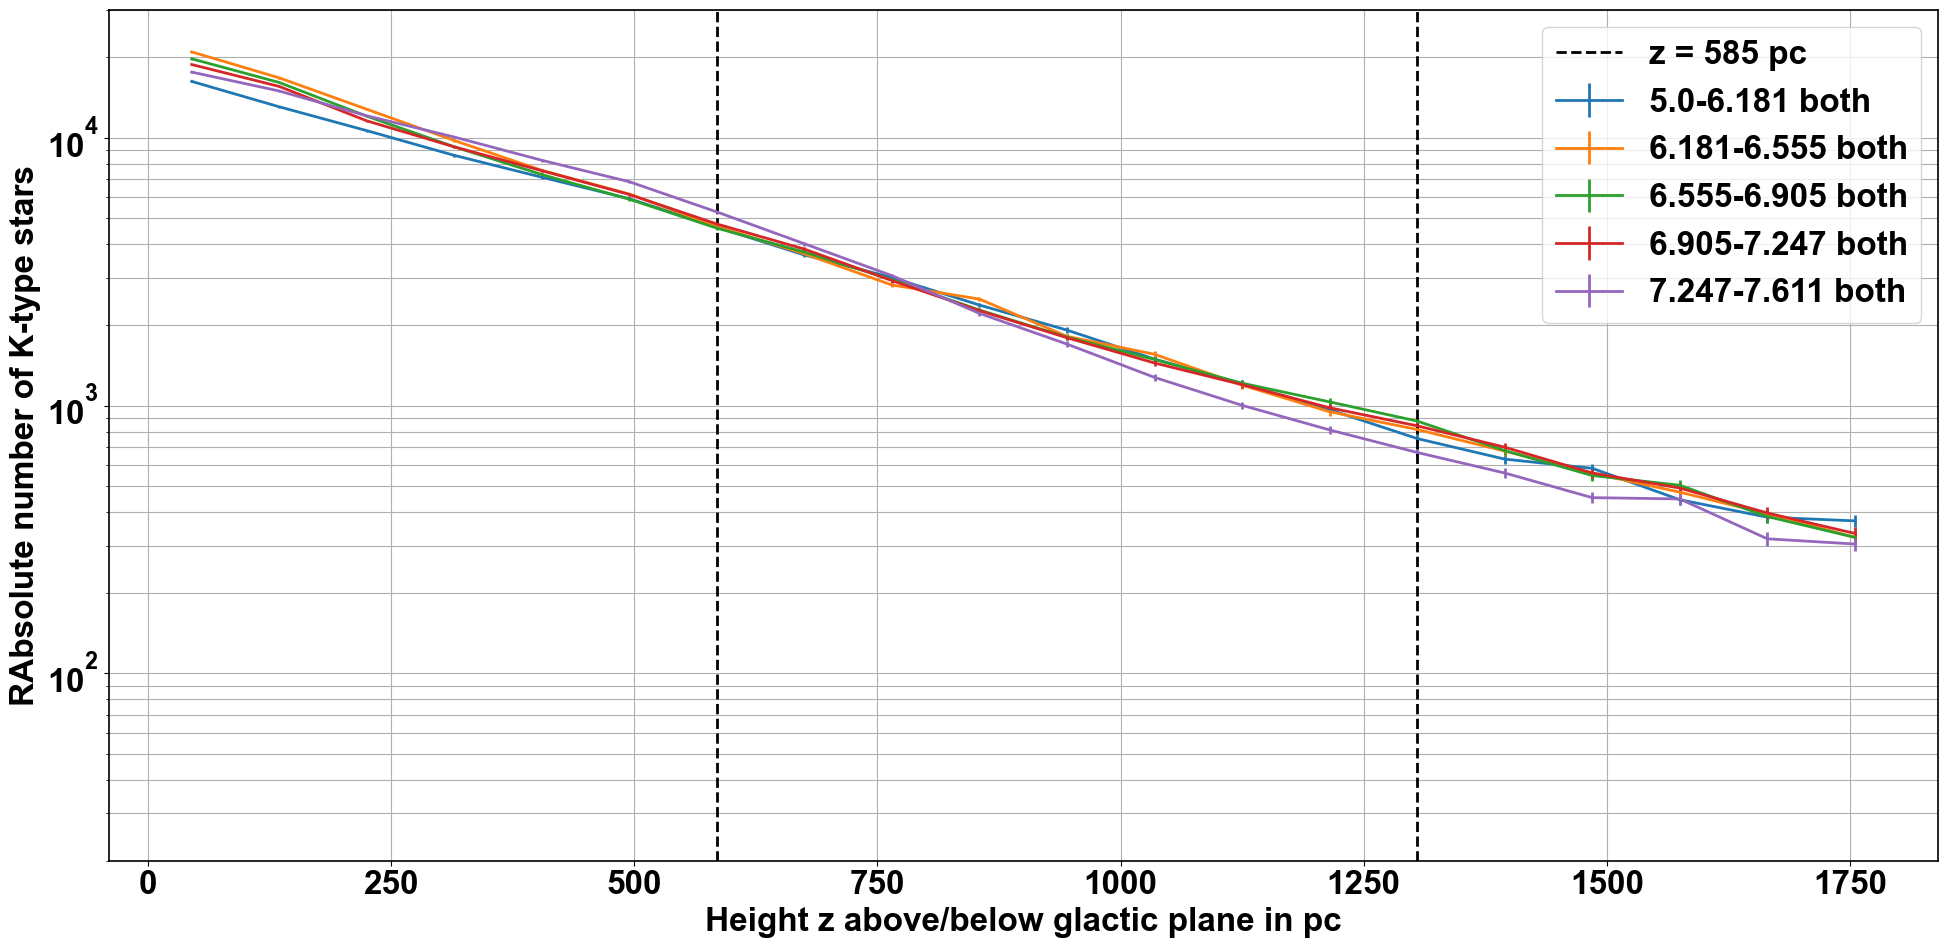

In [71]:
fig, ax = plt.subplots(1,1, figsize=(20,10), gridspec_kw={'height_ratios': [1]}, sharex=True)
ax.set_yscale("log")
ax.set_xlabel("Height z above/below glactic plane in pc")
ax.set_ylabel("RAbsolute number of K-type stars")
ax.set_ylim(20, 3e+4)

def slice(am_min, am_max, n_bin):
    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) + 14.5 #correction for height of the sun above the galactic plane
    
    n, bins = np.histogram(z_np, bins=n_bin, range=(-1800, 1800))
    zz = (bins[1:]+bins[:-1])/2
    pos = np.where(zz >= 0)
    neg = np.where(zz < 0)
    n_sum = (n[pos]+np.flip(n[neg]))
    # ax.errorbar(zz[pos], n[pos], yerr=np.sqrt(n[pos]), label=f"{am_min}-{am_max} pos")
    # ax.errorbar(abs(zz[neg]), n[neg], yerr=np.sqrt(n[neg]), label=f"{am_min}-{am_max} neg")
    ax.errorbar(zz[pos], n_sum, yerr=np.sqrt(n_sum), label=f"{am_min}-{am_max} both")

slice(5.0, 6.181, 40)
slice(6.181, 6.555, 40)
slice(6.555, 6.905, 40)
slice(6.905, 7.247, 40)
slice(7.247, 7.611, 40)

ax.axvline(585, color='black', linestyle='--', label='z = 585 pc')
ax.axvline(1305, color='black', linestyle='--')

ax.grid(which='both')
ax.legend()
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
fig.set_dpi(100)
plt.show()


Requirement: Absolute magnitude between 5.0 and 5.884. Removes an additional 6.14e+05 sources
We are left with 2.79e+04 sources
Requirement: Absolute magnitude between 5.884 and 6.055. Removes an additional 6.14e+05 sources
We are left with 2.79e+04 sources
Requirement: Absolute magnitude between 6.055 and 6.18. Removes an additional 6.14e+05 sources
We are left with 2.79e+04 sources
Requirement: Absolute magnitude between 6.18 and 6.292. Removes an additional 6.14e+05 sources
We are left with 2.81e+04 sources
Requirement: Absolute magnitude between 6.292 and 6.4. Removes an additional 6.14e+05 sources
We are left with 2.78e+04 sources
Requirement: Absolute magnitude between 6.4 and 7.2. Removes an additional 4.30e+05 sources
We are left with 2.12e+05 sources


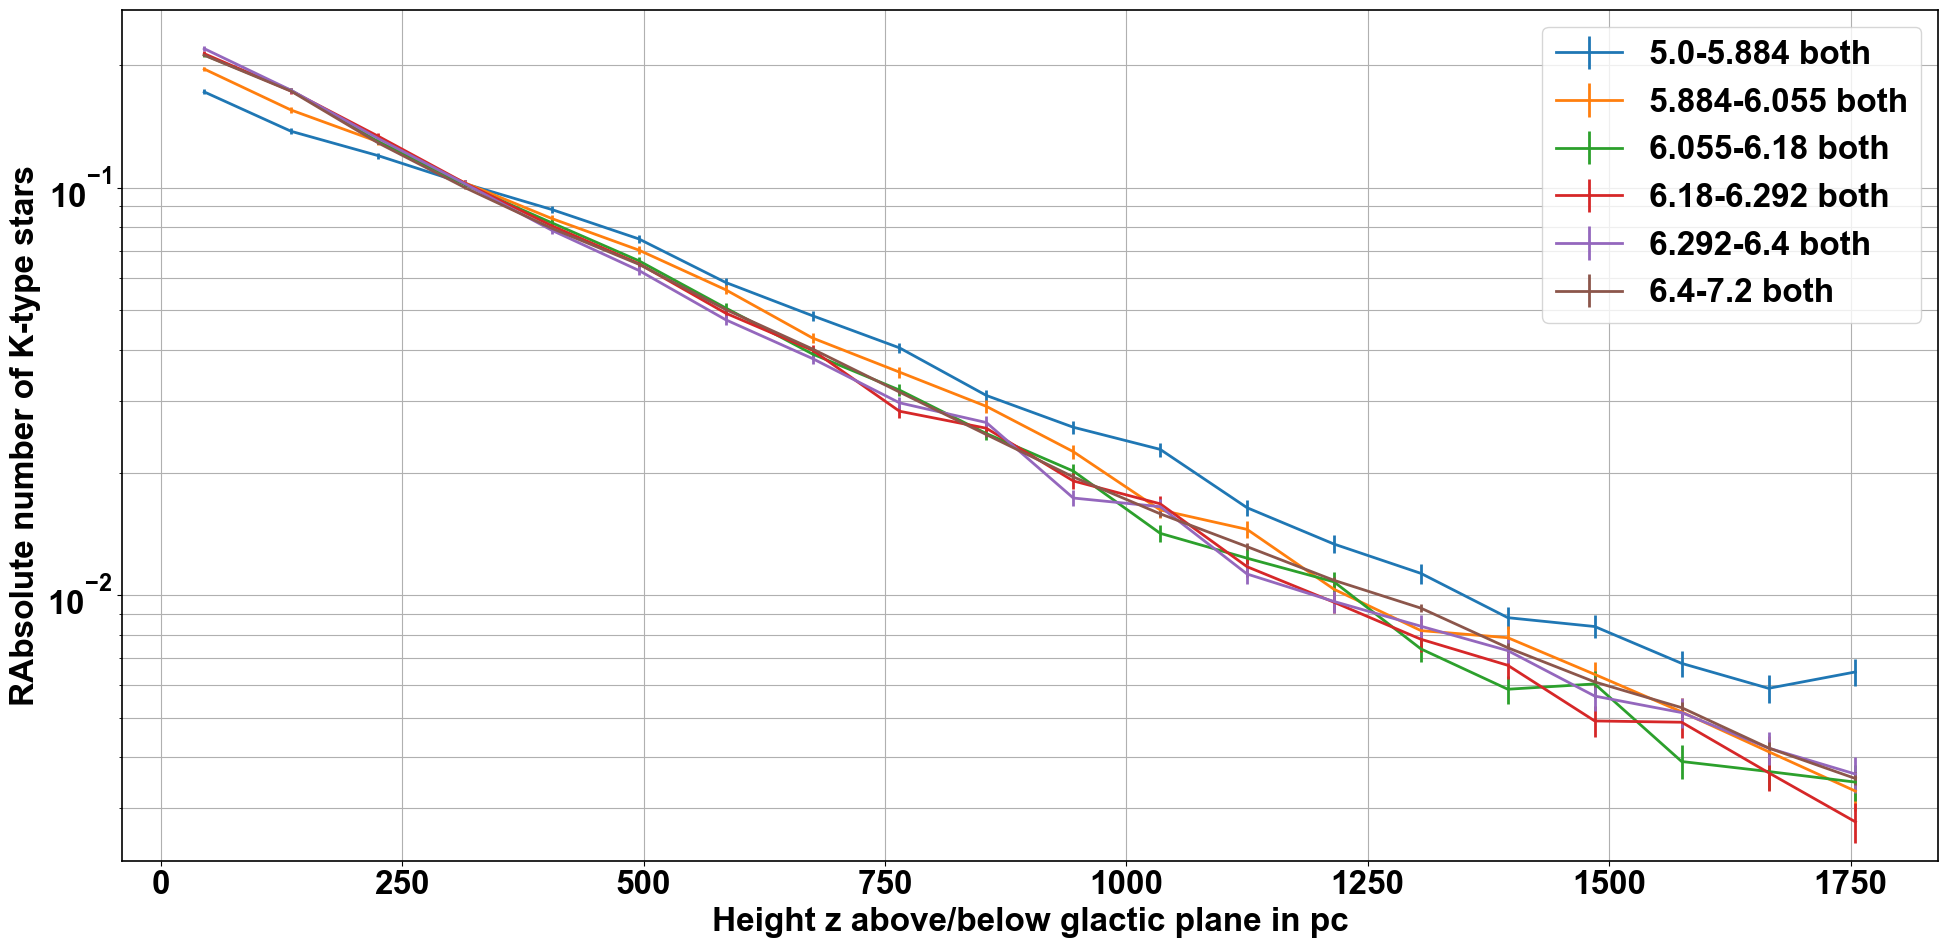

In [72]:
fig, ax = plt.subplots(1,1, figsize=(20,10), gridspec_kw={'height_ratios': [1]}, sharex=True)
ax.set_yscale("log")
ax.set_xlabel("Height z above/below glactic plane in pc")
ax.set_ylabel("RAbsolute number of K-type stars")
# ax.set_ylim(20, 3e+4)

def slice(am_min, am_max, n_bin):
    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) + 14.5 #correction for height of the sun above the galactic plane
    
    n, bins = np.histogram(z_np, bins=n_bin, range=(-1800, 1800))
    zz = (bins[1:]+bins[:-1])/2
    pos = np.where(zz >= 0)
    neg = np.where(zz < 0)
    n_sum = (n[pos]+np.flip(n[neg]))
    # ax.errorbar(zz[pos], n[pos], yerr=np.sqrt(n[pos]), label=f"{am_min}-{am_max} pos")
    # ax.errorbar(abs(zz[neg]), n[neg], yerr=np.sqrt(n[neg]), label=f"{am_min}-{am_max} neg")
    ax.errorbar(zz[pos], n_sum/np.sum(n_sum), yerr=np.sqrt(n_sum)/np.sum(n_sum), label=f"{am_min}-{am_max} both")

slice(5.0, 5.884, 40)
slice(5.884, 6.055, 40)
slice(6.055, 6.180, 40)
slice(6.180, 6.292, 40)
slice(6.292, 6.400, 40)
slice(6.4, 7.2, 40)
ax.grid(which='both')
ax.legend()
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
fig.set_dpi(100)
plt.show()

Requirement: Absolute magnitude between 7.0 and 7.183. Removes an additional 5.93e+05 sources
We are left with 4.89e+04 sources
Requirement: Absolute magnitude between 7.183 and 7.37. Removes an additional 5.93e+05 sources
We are left with 4.89e+04 sources
Requirement: Absolute magnitude between 7.37 and 7.565. Removes an additional 5.93e+05 sources
We are left with 4.90e+04 sources
Requirement: Absolute magnitude between 7.565 and 7.777. Removes an additional 5.93e+05 sources
We are left with 4.91e+04 sources
Requirement: Absolute magnitude between 7.777 and 8.0. Removes an additional 5.93e+05 sources
We are left with 4.90e+04 sources
Requirement: Absolute magnitude between 6.0 and 7.0. Removes an additional 3.89e+05 sources
We are left with 2.53e+05 sources


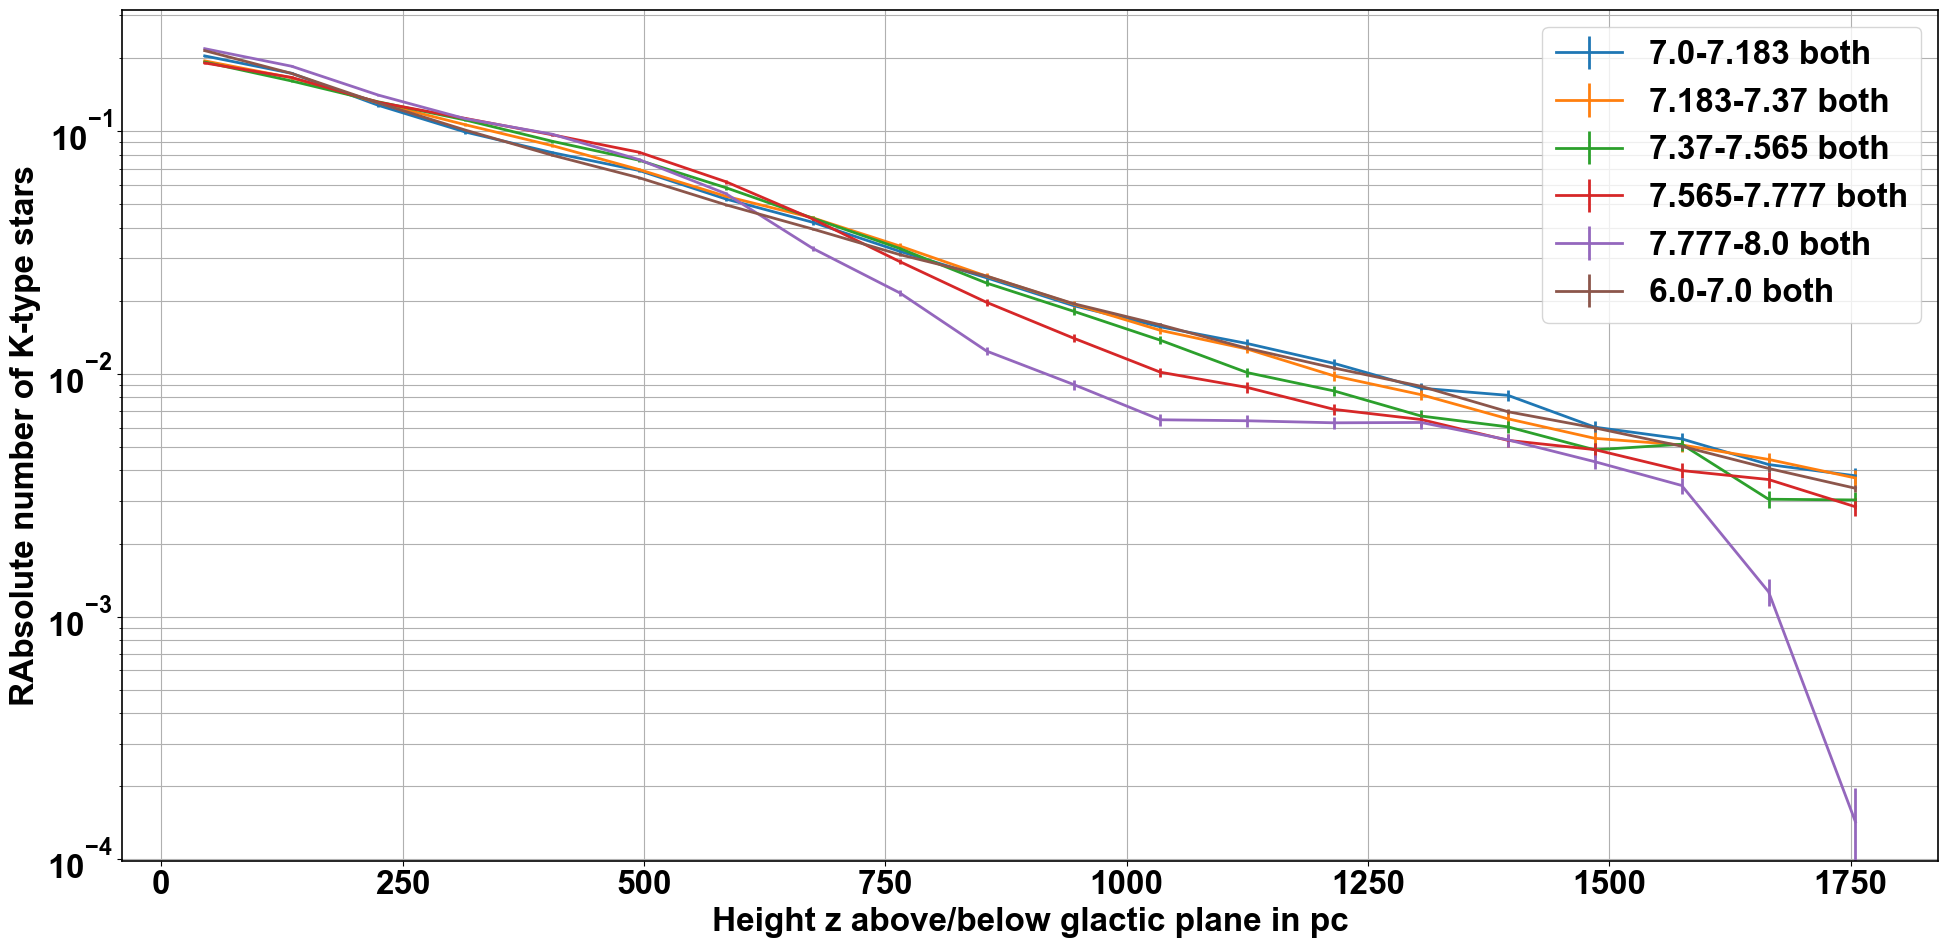

In [73]:
fig, ax = plt.subplots(1,1, figsize=(20,10), gridspec_kw={'height_ratios': [1]}, sharex=True)
ax.set_yscale("log")
ax.set_xlabel("Height z above/below glactic plane in pc")
ax.set_ylabel("RAbsolute number of K-type stars")
# ax.set_ylim(20, 3e+4)

def slice(am_min, am_max, n_bin):
    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) + 14.5 #correction for height of the sun above the galactic plane
    
    n, bins = np.histogram(z_np, bins=n_bin, range=(-1800, 1800))
    zz = (bins[1:]+bins[:-1])/2
    pos = np.where(zz >= 0)
    neg = np.where(zz < 0)
    n_sum = (n[pos]+np.flip(n[neg]))
    # ax.errorbar(zz[pos], n[pos]/np.sum(n[pos]), yerr=np.sqrt(n[pos])/np.sum(n[pos]), label=f"{am_min}-{am_max} pos")
    # ax.errorbar(abs(zz[neg]), n[neg]/np.sum(n[neg]), yerr=np.sqrt(n[neg])/n[neg]/np.sum(n[neg]), label=f"{am_min}-{am_max} neg")
    ax.errorbar(zz[pos], n_sum/np.sum(n_sum), yerr=np.sqrt(n_sum)/np.sum(n_sum), label=f"{am_min}-{am_max} both")

slice(7.0, 7.183, 40)
slice(7.183, 7.370, 40)
slice(7.370, 7.565, 40)
slice(7.565, 7.777, 40)
slice(7.777, 8.0, 40)
slice(6.0, 7.0, 40)
ax.grid(which='both')
ax.legend()
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
fig.set_dpi(100)
plt.show()

Requirement: Absolute magnitude between 6.0 and 6.724. Removes an additional 4.63e+05 sources
We are left with 1.79e+05 sources
Requirement: Absolute magnitude between 6.724 and 7.4. Removes an additional 4.63e+05 sources
We are left with 1.79e+05 sources
Requirement: Absolute magnitude between 5.0 and 6.0. Removes an additional 5.97e+05 sources
We are left with 4.53e+04 sources
Requirement: Absolute magnitude between 7.4 and 8.0. Removes an additional 5.03e+05 sources
We are left with 1.39e+05 sources


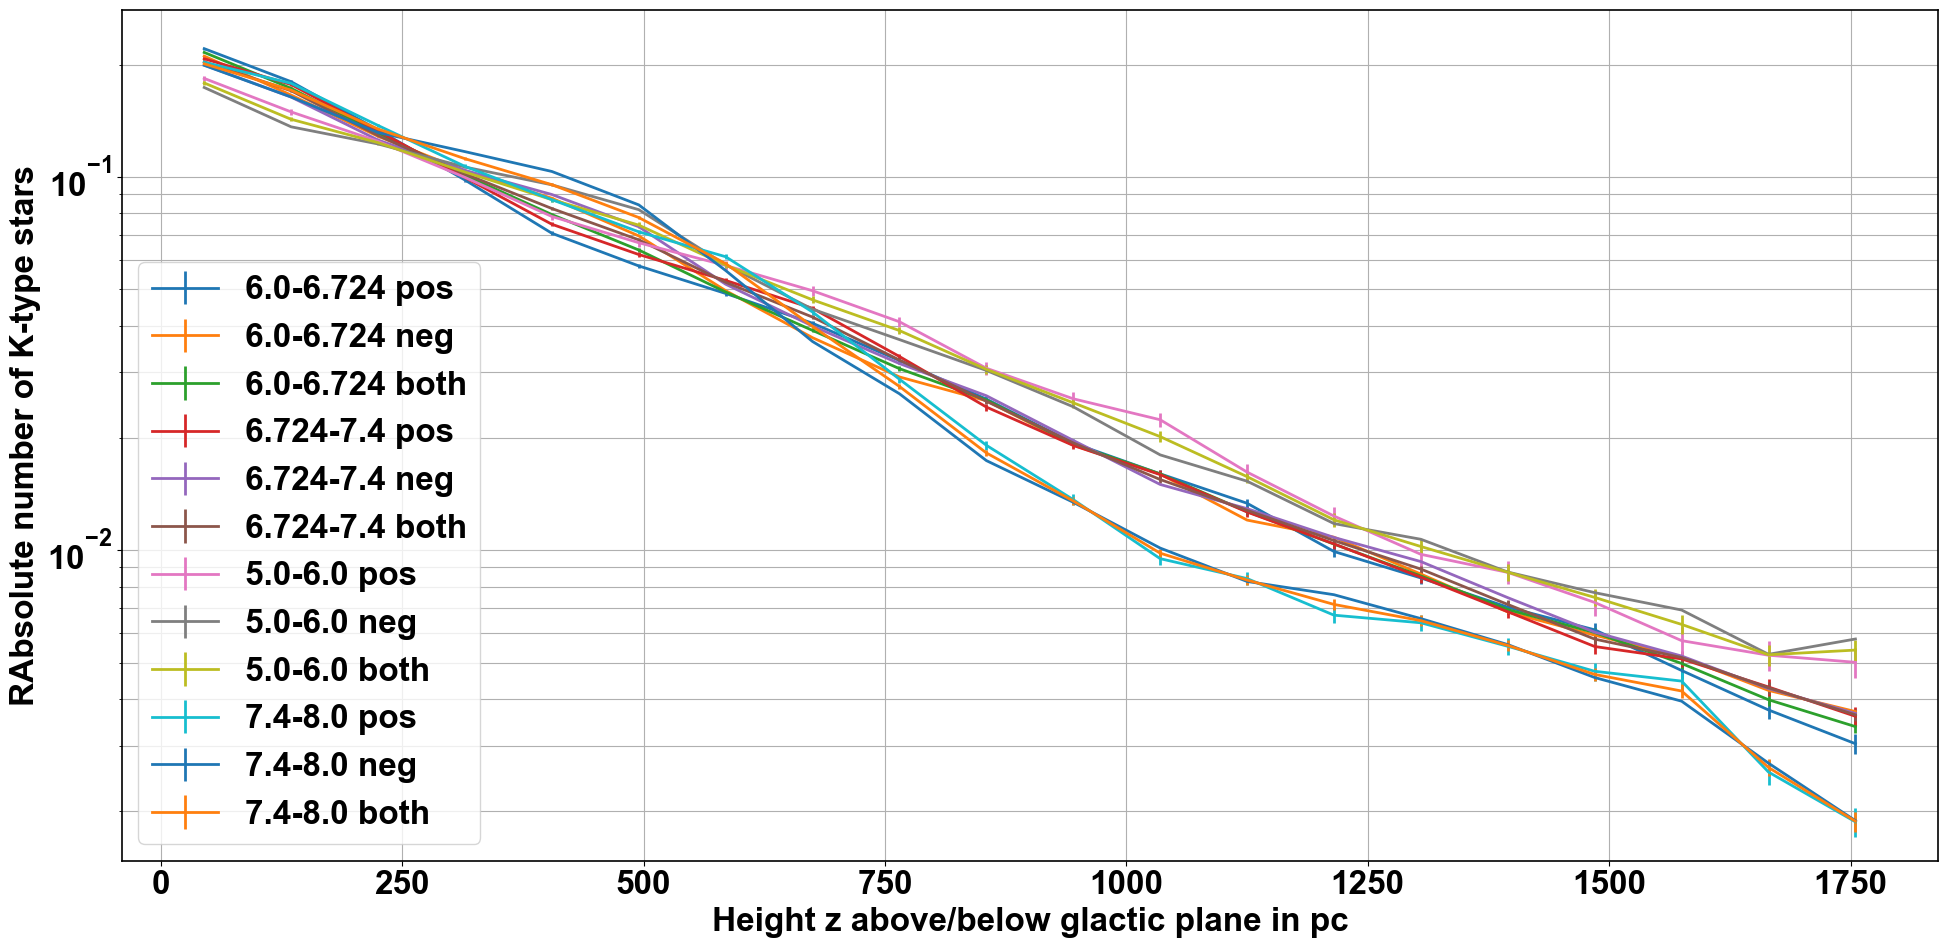

In [74]:
fig, ax = plt.subplots(1,1, figsize=(20,10), gridspec_kw={'height_ratios': [1]}, sharex=True)
ax.set_yscale("log")
ax.set_xlabel("Height z above/below glactic plane in pc")
ax.set_ylabel("RAbsolute number of K-type stars")
# ax.set_ylim(20, 3e+4)

def slice(am_min, am_max, n_bin):
    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) + 14.5 #correction for height of the sun above the galactic plane
    
    n, bins = np.histogram(z_np, bins=n_bin, range=(-1800, 1800))
    zz = (bins[1:]+bins[:-1])/2
    pos = np.where(zz >= 0)
    neg = np.where(zz < 0)
    n_sum = (n[pos]+np.flip(n[neg]))
    ax.errorbar(zz[pos], n[pos]/np.sum(n[pos]), yerr=np.sqrt(n[pos])/np.sum(n[pos]), label=f"{am_min}-{am_max} pos")
    ax.errorbar(abs(zz[neg]), n[neg]/np.sum(n[neg]), yerr=np.sqrt(n[neg])/n[neg]/np.sum(n[neg]), label=f"{am_min}-{am_max} neg")
    ax.errorbar(zz[pos], n_sum/np.sum(n_sum), yerr=np.sqrt(n_sum)/np.sum(n_sum), label=f"{am_min}-{am_max} both")

slice(6.0, 6.724, 40)
slice(6.724, 7.4, 40)

slice(5.0, 6.0, 40)
slice(7.4, 8.0, 40)

ax.grid(which='both')
ax.legend()
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
fig.set_dpi(100)
plt.show()

# Velocity Disperison

Requirement: Absolute magnitude between 5 and 6. Removes an additional 5.97e+05 sources
We are left with 4.53e+04 sources
34154
Requirement: Absolute magnitude between 6 and 7. Removes an additional 3.89e+05 sources
We are left with 2.53e+05 sources
178879
Requirement: Absolute magnitude between 7 and 8. Removes an additional 3.97e+05 sources
We are left with 2.45e+05 sources
136504


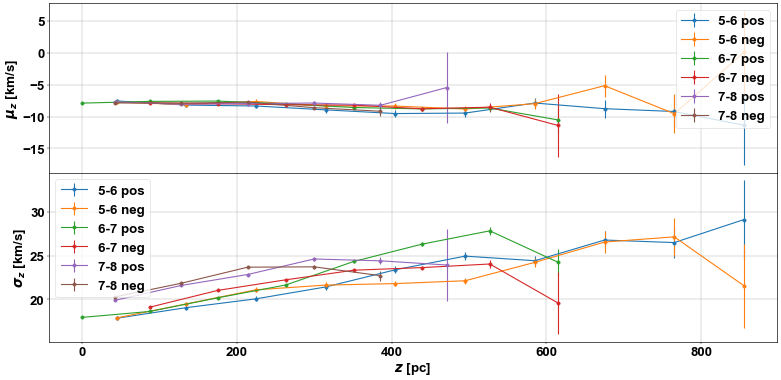

In [75]:
def vel_disp(am_min, am_max, n_bins):
    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

    # Compute vertical velocity dispersion
    vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    hasv = np.isfinite(vz)
    vz = vz[hasv]
    z_np = z_np[hasv]
    print(len(vz))

    bins = np.linspace(-1800, 1800, n_bins+1)
    vz_means = np.array([])
    vz_stds = np.array([])
    evz_means = np.array([])
    evz_stds = np.array([])
    for i in range(len(bins)-1):
        mask = (z_np >= bins[i]) & (z_np < bins[i+1])
        if sum(mask) >= 10:
            vz_means = np.append(vz_means, np.mean(vz[mask]))
            vz_stds = np.append(vz_stds, np.std(vz[mask], ddof=1))
            evz_means = np.append(evz_means, np.std(vz[mask], ddof=1)/np.sqrt(np.sum(mask)))
            evz_stds = np.append(evz_stds, np.std(vz[mask], ddof=1)/np.sqrt(2*(np.sum(mask)-1)))
        else:
            vz_means = np.append(vz_means, np.nan)
            vz_stds = np.append(vz_stds, np.nan)
            evz_means = np.append(evz_means, np.nan)
            evz_stds = np.append(evz_stds, np.nan)
    
    z = (bins[1:]+bins[:-1])/2
    i = np.isnan(vz_stds)

    return vz_means[~i], vz_stds[~i], evz_means[~i], evz_stds[~i], z[~i]

fig, ax = plt.subplots(2,1, figsize=(20,10))
for am, n_bin in zip([[5,6], [6,7], [7,8]], [40, 41, 42]):
    vz_means, vz_stds, evz_means, evz_stds, z= vel_disp(am[0], am[1], n_bin)
    pos = np.where(z>=0)
    neg = np.where(z<0)
    ax[0].errorbar(z[pos], vz_means[pos], yerr=evz_means[pos], marker='o',label=f"{am[0]}-{am[1]} pos")
    ax[0].errorbar(abs(z[neg]), vz_means[neg], yerr=evz_means[neg], marker='o',label=f"{am[0]}-{am[1]} neg")
    ax[1].errorbar(z[pos], vz_stds[pos], yerr=evz_stds[pos], marker='o', label=f"{am[0]}-{am[1]} pos")
    ax[1].errorbar(abs(z[neg]), vz_stds[neg], yerr=evz_stds[neg], marker='o', label=f"{am[0]}-{am[1]} neg")
ax[0].set_xlabel(r"$z$ [pc]")
ax[0].set_ylabel(r"$\mu_z$ [km/s]")
ax[0].grid()
ax[0].legend()
ax[1].set_xlabel(r"$z$ [pc]")
ax[1].set_ylabel(r"$\sigma_z$ [km/s]")
ax[1].grid()
ax[1].legend()
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
fig.set_dpi(40)